In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import scipy as sci
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

Givet et signal med sampleværdier x = [3, 0, -5, 1] for n=0, 1, 2, 3. Udregn i hånden en 4-punkts DFT og
check resultatet i Matlab. Eksempelvis ved at finde middelværdien og sammenligne med D

In [14]:
x_n = np.array([3,0,-5,1])

N = len(x_n)

n = np.arange(N)

m = n.copy()

x_m = np.zeros(N,dtype=complex)

W_N = np.exp(-2j * np.pi / N)


x_m[0] += x_n[0]*W_N**(0*m[0])
x_m[0] += x_n[1]*W_N**(1*m[0])
x_m[0] += x_n[2]*W_N**(2*m[0])
x_m[0] += x_n[3]*W_N**(3*m[0])

x_m[1] += x_n[0]*W_N**(0*m[1])
x_m[1] += x_n[1]*W_N**(1*m[1])
x_m[1] += x_n[2]*W_N**(2*m[1])
x_m[1] += x_n[3]*W_N**(3*m[1])

x_m[2] += x_n[0]*W_N**(0*m[2])
x_m[2] += x_n[1]*W_N**(1*m[2])
x_m[2] += x_n[2]*W_N**(2*m[2])
x_m[2] += x_n[3]*W_N**(3*m[2])

x_m[3] += x_n[0]*W_N**(0*m[3])
x_m[3] += x_n[1]*W_N**(1*m[3])
x_m[3] += x_n[2]*W_N**(2*m[3])
x_m[3] += x_n[3]*W_N**(3*m[3])

print(x_m)


program_x = np.fft.fft(x_n)
print(program_x)


[-1.+0.00000000e+00j  8.+1.00000000e+00j -3.-1.59204084e-15j
  8.-1.00000000e+00j]
[-1.+0.j  8.+1.j -3.+0.j  8.-1.j]


Generer i Matlab en sinuskurve med f0 = 400Hz, amplitude på 1 og varighed 1 sekund. Samplefrekvensen er
12kHz. Lav en DFT på sinussen og plot størrelsen. Gentag øvelsen, nu med varighed 100ms og DC-forskudt
+2 volt. Gem DFT-resultaterne i en fil kaldet result22.mat. Gem også den første sinus i en wav fil.

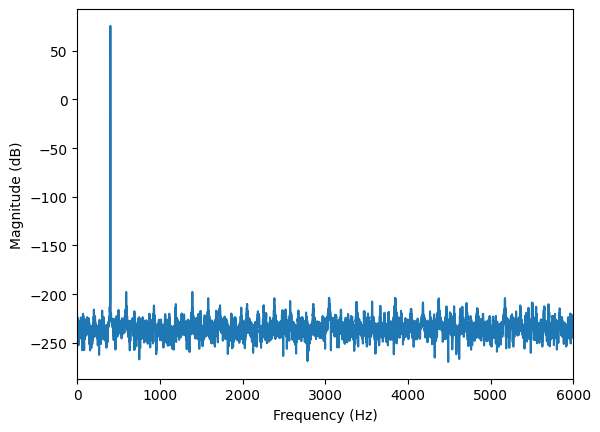

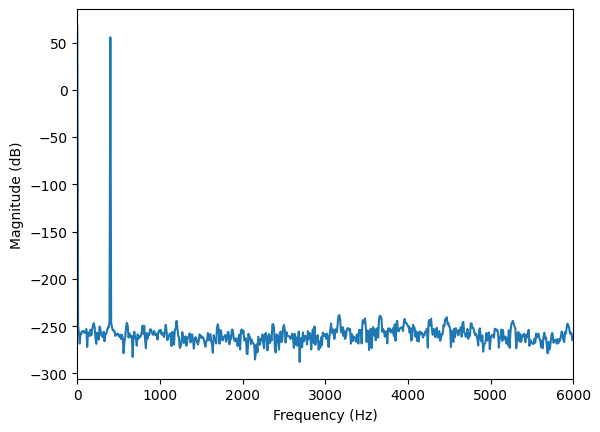

In [62]:
f_0 = 400

a_0 = 1

t_end = 1

f_s = 12000

t_s = 1/f_s

t = np.arange(0, t_end, t_s)

s_1 = a_0 * np.sin(2 * np.pi * f_0 * t)

f_s_1 = np.fft.fft(s_1)

freqs_1 = np.arange(len(s_1))*f_s/len(s_1)


plt.plot(freqs_1 , 20*np.log10(np.abs(f_s_1)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, f_s/2)
plt.show()




t_2 = np.arange(0, 0.1, t_s)

s_2 = a_0 * np.sin(2 * np.pi * f_0 * t_2) + 2

f_s_2 = np.fft.fft(s_2)

freqs_2 = np.arange(len(s_2))*f_s/len(s_2)


plt.plot(freqs_2, 20*np.log10(np.abs(f_s_2)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, f_s/2)
plt.show()

Plot DFT resultaterne fra opgave 2.2 på logaritmisk frekvensakse. Amplitudeskaleringerne skal være
korrekte, og amplituderne skal vises i decibel. Plot kun den fysisk meningsfulde del af spektren

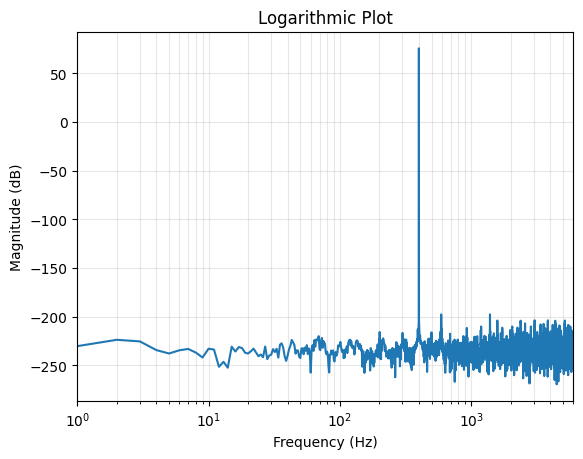

10.0


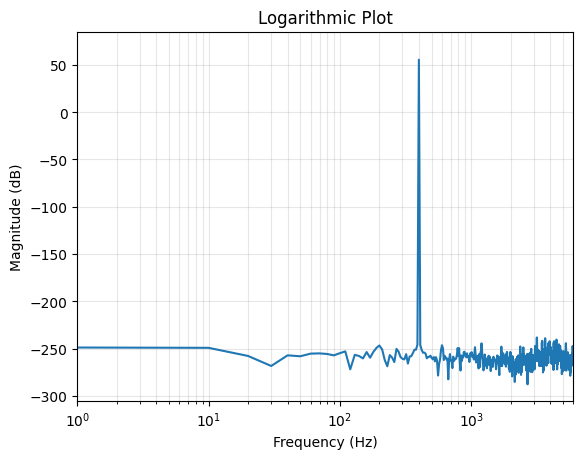

In [66]:



# Use ONE of these based on scale:
plt.semilogx(freqs_1,20*np.log10(np.abs(f_s_1)))  # Log x-axis only
# plt.semilogy(x, y, 'o-', color='color')  # Log y-axis only
# plt.loglog(x, y, 'o-', color='color')   # Log both axes
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Logarithmic Plot')
plt.grid(True, which='both', alpha=0.3)
plt.xlim(1, f_s/2)
plt.show()

print(f_s/len(s_2))

# Use ONE of these based on scale:
plt.semilogx(freqs_2,20*np.log10(np.abs(f_s_2)))  # Log x-axis only
# plt.semilogy(x, y, 'o-', color='color')  # Log y-axis only
# plt.loglog(x, y, 'o-', color='color')   # Log both axes
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Logarithmic Plot')
plt.grid(True, which='both', alpha=0.3)
plt.xlim(1, f_s/2)
plt.show()

Lav DFT på signalet y(n) = [6, 1, -2, -1, 3, 3, 4, -1] for n=0, 1, ..., 7. Antag at samplefrekvensen er 240Hz og
bestem frekvensopløsningen. Hvad er analysefrekvensen for bin m=5? Lav invers transformation IDFT på
Y(m) og check med y(n).

Frekvensopløsning: 30.0
analyse_frekvens_5: 150.0


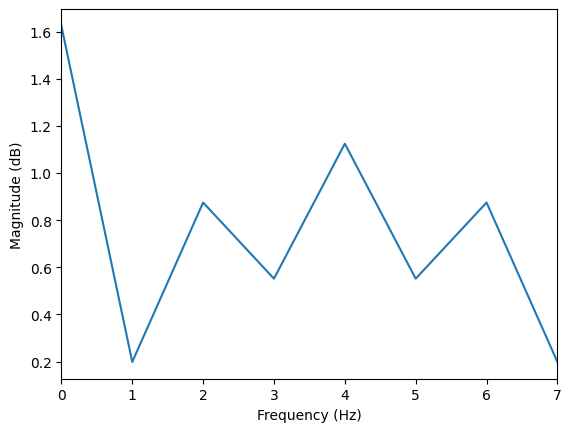

In [ ]:
y_n = np.array([6,1,-2,-1,3,3,4,-1])
n_bin = np.arange(len(y_n))

f_s = 240
t_s = 1/f_s

f_opløsning = f_s/len(y_n)
print(f"Frekvensopløsning: {f_opløsning}")

analyse_frekvens_5 = 5*f_opløsning
print(f"analyse_frekvens_5: {analyse_frekvens_5}")



# Compute inverse FFT
x = np.fft.ifft(y_n)

# Take real part (imaginary part should be near zero due to numerical error)
x = np.real(x)

plt.plot(x)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0, 7)  
plt.show()